# CC3092 - Laboratorio 8: entrega final

**Task 3:** embeddings contextuales (BERT) frente a embeddings estáticos (Word2Vec).  
**Task 4:** preguntas de análisis sobre GPT, BERT y el paradigma de preentrenar y adaptar.

En el Task 3 se usan palabras polisémicas (`banco`, `copa`, `vela`) en oraciones donde tienen significados distintos. El objetivo es medir si la representación de una misma palabra cambia según su contexto:

- **3.1** extracción del embedding de la última capa de `bert-base-multilingual-cased` para la palabra objetivo de cada oración.
- **3.2a** similitud coseno entre las instancias de la misma palabra con BERT y con Word2Vec.
- **3.2b** visualización de los embeddings de BERT con PCA en dos dimensiones.

Los Task 1 y 2 (Mini-GPT y estrategias de muestreo) están en `Lab8_Entrega_Parcial.ipynb`.

## 1. Configuración y oraciones

Cada oración se registra con su palabra objetivo y una etiqueta del significado que tiene en ese contexto. La etiqueta no entra al modelo; solo se usa para nombrar los pares y colorear la gráfica de PCA.

In [1]:
import os
import sys
from pathlib import Path

# El notebook vive en notebooks/; data/, outputs/ y lab8_minigpt.py están en la raíz.
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from transformers import AutoModel, AutoTokenizer

SEED = 42
BERT_NAME = 'bert-base-multilingual-cased'
WORD2VEC_NAME = 'word2vec-google-news-300'

torch.manual_seed(SEED)
Path('outputs').mkdir(exist_ok=True)

SENTENCES = [
    ('El banco central anunció una subida de tasas de interés.', 'banco', 'banco-finanzas'),
    ('Me senté en el banco del parque a leer el periódico.', 'banco', 'banco-asiento'),
    ('El banco de peces se movió velozmente ante el tiburón.', 'banco', 'banco-peces'),
    ('El equipo levantó la copa del torneo ante miles de aficionados.', 'copa', 'copa-trofeo'),
    ('Sirvió una copa de vino tinto para acompañar la cena.', 'copa', 'copa-recipiente'),
    ('El velero desplegó su vela para aprovechar el viento.', 'vela', 'vela-navegación'),
    ('Encendió una vela para iluminar el cuarto durante el apagón.', 'vela', 'vela-iluminación'),
]

sentences_df = pd.DataFrame(SENTENCES, columns=['oración', 'palabra', 'significado'])
sentences_df

C:\Users\richi\Documents\2026_S2_Local\Deep-Learning\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,oración,palabra,significado
0,El banco central anunció una subida de tasas d...,banco,banco-finanzas
1,Me senté en el banco del parque a leer el peri...,banco,banco-asiento
2,El banco de peces se movió velozmente ante el ...,banco,banco-peces
3,El equipo levantó la copa del torneo ante mile...,copa,copa-trofeo
4,Sirvió una copa de vino tinto para acompañar l...,copa,copa-recipiente
5,El velero desplegó su vela para aprovechar el ...,vela,vela-navegación
6,Encendió una vela para iluminar el cuarto dura...,vela,vela-iluminación


## 2. Task 3.1 - carga de BERT

`from_pretrained` descarga del Hub de Hugging Face el repositorio `bert-base-multilingual-cased` (configuración, pesos y vocabulario) la primera vez, y en adelante lo lee de la caché local. `model.eval()` desactiva el dropout para que el mismo texto produzca siempre el mismo embedding.

Antes de extraer embeddings se verifica que el modelo cargado sea el esperado: arquitectura BERT, 12 capas, dimensión oculta 768 y vocabulario multilingüe. También se registra el commit del repositorio descargado para que el experimento sea reproducible.

El reporte de carga marca como `UNEXPECTED` los pesos `cls.predictions.*` y `cls.seq_relationship.*`. Son las cabezas de preentrenamiento de BERT (predicción de palabras enmascaradas y de la siguiente oración). `AutoModel` carga solo el encoder, que es lo que produce los embeddings, así que esas cabezas sobran y es correcto que se descarten.

In [2]:
from huggingface_hub import try_to_load_from_cache

tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert = AutoModel.from_pretrained(BERT_NAME)
bert.eval()

config = bert.config
print('Modelo:', config.name_or_path)
print('Clase:', type(bert).__name__)
# La caché guarda cada versión en snapshots/<commit>/; ese nombre identifica la versión descargada.
cached_config = Path(try_to_load_from_cache(BERT_NAME, 'config.json'))
print('Commit del repositorio:', cached_config.parent.name)
print('Capas:', config.num_hidden_layers)
print('Cabezas de atención:', config.num_attention_heads)
print('Dimensión oculta:', config.hidden_size)
print('Vocabulario:', f'{tokenizer.vocab_size:,} tokens')
print('Parámetros:', f'{sum(p.numel() for p in bert.parameters()):,}')

assert type(bert).__name__ == 'BertModel'
assert config.num_hidden_layers == 12
assert config.hidden_size == 768


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights:  13%|█▎        | 26/199 [00:00<00:00, 227.16it/s]


Loading weights:  25%|██▍       | 49/199 [00:00<00:00, 181.72it/s]


Loading weights:  34%|███▍      | 68/199 [00:00<00:00, 172.29it/s]


Loading weights:  48%|████▊     | 96/199 [00:00<00:00, 199.30it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 396.62it/s]


[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo: bert-base-multilingual-cased
Clase: BertModel
Commit del repositorio: 3f076fdb1ab68d5b2880cb87a0886f315b8146f8
Capas: 12
Cabezas de atención: 12
Dimensión oculta: 768
Vocabulario: 119,547 tokens
Parámetros: 177,853,440


## 3. Task 3.1 - tokenización y ubicación de la palabra objetivo

BERT no recibe palabras sino tokens WordPiece: una palabra frecuente es un solo token y una poco frecuente se parte en fragmentos que empiezan con `##`. El tokenizer además agrega `[CLS]` al inicio y `[SEP]` al final.

Para ubicar la palabra objetivo se busca su posición en caracteres dentro de la oración (como palabra completa, para que `vela` no coincida dentro de `velero`) y se eligen los tokens cuyo rango de caracteres (`offset_mapping`) cae dentro de ella. Así se toma el token de la palabra objetivo y nunca `[CLS]`, cuyo rango es vacío.

In [3]:
import re


def target_token_positions(sentence, word):
    """Tokeniza la oración y devuelve los índices de los tokens de `word`."""
    match = re.search(rf'\b{re.escape(word)}\b', sentence)
    if match is None:
        raise ValueError(f'{word!r} no aparece en {sentence!r}')
    start, end = match.span()

    encoding = tokenizer(sentence, return_offsets_mapping=True, return_tensors='pt')
    offsets = encoding.pop('offset_mapping')[0].tolist()
    # Los tokens especiales tienen rango vacío (0, 0) y quedan fuera.
    positions = [
        index for index, (token_start, token_end) in enumerate(offsets)
        if token_start < token_end and token_start >= start and token_end <= end
    ]
    return encoding, positions


for sentence, word, meaning in SENTENCES:
    encoding, positions = target_token_positions(sentence, word)
    tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
    marked = [f'[[{token}]]' if index in positions else token for index, token in enumerate(tokens)]
    print(f'{meaning}: posiciones {positions} -> {[tokens[i] for i in positions]}')
    print('   ', ' '.join(marked))

    assert positions and 0 not in positions

banco-finanzas: posiciones [2] -> ['banco']
    [CLS] El [[banco]] central anunció una sub ##ida de tasa ##s de interés . [SEP]
banco-asiento: posiciones [6] -> ['banco']
    [CLS] Me sent ##é en el [[banco]] del parque a leer el periódico . [SEP]
banco-peces: posiciones [2] -> ['banco']
    [CLS] El [[banco]] de peces se mo ##vió vel ##oz ##mente ante el ti ##bur ##ón . [SEP]
copa-trofeo: posiciones [6] -> ['copa']
    [CLS] El equipo leva ##ntó la [[copa]] del torneo ante miles de af ##icionados . [SEP]
copa-recipiente: posiciones [4] -> ['copa']
    [CLS] Sir ##vió una [[copa]] de vino tin ##to para ac ##om ##pa ##ñar la cena . [SEP]
vela-navegación: posiciones [8] -> ['vela']
    [CLS] El vele ##ro des ##ple ##gó su [[vela]] para ap ##rove ##char el viento . [SEP]
vela-iluminación: posiciones [5] -> ['vela']
    [CLS] En ##cend ##ió una [[vela]] para il ##umi ##nar el cuarto durante el apa ##gón . [SEP]


En las siete oraciones la palabra objetivo (`banco`, `copa`, `vela`) es un solo token del vocabulario, así que su embedding es directamente el vector de salida en esa posición. Las palabras de alrededor sí se parten (por ejemplo `vele ##ro`, `apa ##gón`), pero eso no afecta la extracción. Si la palabra objetivo se partiera, la función de la sección siguiente promediaría los vectores de sus fragmentos.

## 4. Task 3.1 - extracción de los embeddings contextuales

Cada oración se pasa completa por BERT. La salida `last_hidden_state` tiene forma `(1, tokens, 768)`: un vector de la última capa por cada token. Se toma el vector en la posición de la palabra objetivo (o el promedio de sus fragmentos, si estuviera partida). Como BERT es un encoder sin máscara causal, ese vector ya incorpora información de las palabras a ambos lados.

`torch.no_grad()` evita guardar el grafo de gradientes, porque solo se hace inferencia.

In [4]:
@torch.no_grad()
def target_embedding(sentence, word):
    """Embedding de la última capa de BERT para `word` dentro de `sentence`."""
    encoding, positions = target_token_positions(sentence, word)
    outputs = bert(**encoding)
    # last_hidden_state: (1, tokens, 768) -> vectores de la palabra objetivo -> (768,)
    return outputs.last_hidden_state[0, positions].mean(dim=0)


bert_embeddings = torch.stack([target_embedding(sentence, word) for sentence, word, _ in SENTENCES])
meanings = [meaning for _, _, meaning in SENTENCES]

print('Matriz de embeddings:', tuple(bert_embeddings.shape))
for (sentence, word, meaning), vector in zip(SENTENCES, bert_embeddings):
    encoding, positions = target_token_positions(sentence, word)
    token_id = encoding['input_ids'][0, positions].tolist()
    print(f'{meaning:<17} id de entrada={token_id}  norma={vector.norm():6.3f}  primeros valores={vector[:4].numpy().round(3)}')

assert bert_embeddings.shape == (len(SENTENCES), 768)

Matriz de embeddings: (7, 768)
banco-finanzas    id de entrada=[55379]  norma=13.895  primeros valores=[-0.566 -0.738  0.594 -0.141]
banco-asiento     id de entrada=[55379]  norma=14.320  primeros valores=[ 0.149 -0.21   0.656  0.195]
banco-peces       id de entrada=[55379]  norma=13.144  primeros valores=[ 0.005 -0.574  0.939  0.277]
copa-trofeo       id de entrada=[39313]  norma=12.738  primeros valores=[-0.055 -0.153 -0.183  0.037]
copa-recipiente   id de entrada=[39313]  norma=14.579  primeros valores=[ 0.029 -0.787  0.34   0.43 ]
vela-navegación   id de entrada=[89018]  norma=13.856  primeros valores=[-0.368 -1.294 -0.521  0.342]
vela-iluminación  id de entrada=[89018]  norma=13.636  primeros valores=[-0.135 -1.138  0.18   0.467]


Se obtuvieron siete vectores de dimensión 768. Las tres instancias de `banco` entran a BERT con el mismo id de token (55379), y lo mismo ocurre con `copa` (39313) y `vela` (89018); aun así, sus vectores de salida son distintos. Por ejemplo, la primera componente de `banco` vale -0.566 en el contexto financiero, 0.149 en el del parque y 0.005 en el de los peces. La entrada es idéntica y la diferencia la produce el contexto, a través de las 12 capas de self-attention. La sección siguiente mide cuánto difieren con la similitud coseno.

## 5. Task 3.2a - similitud coseno entre contextos (BERT)

La similitud coseno mide el ángulo entre dos vectores, sin importar su longitud:

$$\operatorname{sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u}^\top \mathbf{v}}{\lVert \mathbf{u} \rVert \cdot \lVert \mathbf{v} \rVert}$$

Vale 1 si apuntan en la misma dirección, 0 si son ortogonales y -1 si son opuestos. La función se implementa directamente con esa fórmula y se compara contra `torch.nn.functional.cosine_similarity` como verificación. Se calculan todos los pares de instancias de la misma palabra: tres para `banco` y uno para `copa` y `vela`.

In [5]:
from itertools import combinations


def cosine(u, v):
    """sim(u, v) = u·v / (||u|| ||v||)."""
    return float(u @ v / (u.norm() * v.norm()))


def same_word_pairs():
    """Índices (i, j) de todas las parejas de oraciones con la misma palabra objetivo."""
    return [
        (i, j) for i, j in combinations(range(len(SENTENCES)), 2)
        if SENTENCES[i][1] == SENTENCES[j][1]
    ]


pairs = same_word_pairs()
bert_rows = []
for i, j in pairs:
    similarity = cosine(bert_embeddings[i], bert_embeddings[j])
    reference = torch.nn.functional.cosine_similarity(bert_embeddings[i], bert_embeddings[j], dim=0)
    assert abs(similarity - reference.item()) < 1e-5
    bert_rows.append({
        'palabra': SENTENCES[i][1],
        'contexto 1': meanings[i],
        'contexto 2': meanings[j],
        'coseno BERT': round(similarity, 4),
    })

assert abs(cosine(bert_embeddings[0], bert_embeddings[0]) - 1.0) < 1e-5
bert_table = pd.DataFrame(bert_rows)
bert_table

,palabra,contexto 1,contexto 2,coseno BERT
0,banco,banco-finanzas,banco-asiento,0.5753
1,banco,banco-finanzas,banco-peces,0.6603
2,banco,banco-asiento,banco-peces,0.6496
3,copa,copa-trofeo,copa-recipiente,0.5667
4,vela,vela-navegación,vela-iluminación,0.7999


**Interpretación.** Ningún par llega a 1: los cosenos van de 0.567 a 0.800, aunque las tres palabras entran a BERT con el mismo token. El contexto movió la representación de cada instancia.

- `copa` (trofeo / recipiente) tiene la similitud más baja, 0.567, seguida de `banco` finanzas / asiento con 0.575.
- En `banco`, finanzas / peces (0.660) sale más parecido que finanzas / asiento (0.575), aunque ambos son significados distintos. Las oraciones de finanzas y de peces empiezan igual (`El banco ...`) y la palabra queda en la misma posición, mientras que la del parque tiene otra estructura (`Me senté en el banco ...`). El embedding contextual refleja el significado, pero también la sintaxis y la posición.
- `vela` tiene la similitud más alta, 0.800. Una explicación posible es que las dos oraciones comparten la estructura `vela para` + infinitivo (`vela para aprovechar`, `vela para iluminar`).

Los valores conviene leerlos en términos relativos. Los embeddings de BERT tienden a ocupar una región estrecha del espacio (anisotropía), así que incluso palabras sin relación suelen tener coseno positivo. Por eso un 0.57 no significa "57 % del mismo significado": lo informativo es que los pares no llegan a 1 y que difieren entre sí.

## 6. Task 3.2a - comparación con Word2Vec (embeddings estáticos)

Se usa `word2vec-google-news-300`, el modelo Word2Vec preentrenado que distribuye `gensim` (vectores de dimensión 300 entrenados con noticias de Google News). Un embedding estático es una tabla: cada palabra del vocabulario tiene un único vector, sin importar la oración en la que aparezca. Para cada instancia se consulta el vector de la palabra objetivo y se calcula el coseno con la misma función de la sección anterior.

El modelo se entrenó con texto en inglés. Antes de comparar se verifica si cada palabra objetivo está en su vocabulario y qué vecinos más cercanos tiene, para saber qué representa ese vector.

In [6]:
import gensim.downloader as gensim_api

word2vec = gensim_api.load(WORD2VEC_NAME)
print(f'Vocabulario Word2Vec: {len(word2vec.key_to_index):,} palabras | dimensión: {word2vec.vector_size}')

for word in sorted({word for _, word, _ in SENTENCES}):
    if word not in word2vec.key_to_index:
        print(f'\n{word!r}: no está en el vocabulario')
        continue
    neighbors = ', '.join(f'{other} ({score:.2f})' for other, score in word2vec.most_similar(word, topn=8))
    print(f'\n{word!r}: posición {word2vec.key_to_index[word]:,} por frecuencia')
    print('  vecinos más cercanos:', neighbors)

Vocabulario Word2Vec: 3,000,000 palabras | dimensión: 300



'banco': posición 929,039 por frecuencia
  vecinos más cercanos: arriba (0.52), forza (0.52), deus (0.51), apenas (0.51), próxima (0.51), mesi (0.50), nostra (0.50), nuova (0.50)



'copa': posición 1,068,243 por frecuencia
  vecinos más cercanos: boca (0.63), diez (0.62), você (0.62), ojos (0.62), solamente (0.62), el_es (0.61), fresca (0.61), comida (0.61)



'vela': posición 894,302 por frecuencia
  vecinos más cercanos: roberto (0.62), feliz (0.61), eto (0.60), tú (0.60), clase (0.60), suerte (0.59), quién (0.59), eso (0.59)


In [7]:
# El vector estático depende solo de la palabra, no de la oración.
word2vec_embeddings = [torch.from_numpy(word2vec[word].copy()) for _, word, _ in SENTENCES]

comparison = bert_table.copy()
comparison['coseno Word2Vec'] = [
    round(cosine(word2vec_embeddings[i], word2vec_embeddings[j]), 4) for i, j in pairs
]
comparison['diferencia'] = (comparison['coseno Word2Vec'] - comparison['coseno BERT']).round(4)

for i, j in pairs:
    assert torch.equal(word2vec_embeddings[i], word2vec_embeddings[j])
comparison

,palabra,contexto 1,contexto 2,coseno BERT,coseno Word2Vec,diferencia
0,banco,banco-finanzas,banco-asiento,0.5753,1.0,0.4247
1,banco,banco-finanzas,banco-peces,0.6603,1.0,0.3397
2,banco,banco-asiento,banco-peces,0.6496,1.0,0.3504
3,copa,copa-trofeo,copa-recipiente,0.5667,1.0,0.4333
4,vela,vela-navegación,vela-iluminación,0.7999,1.0,0.2001


**Comparación BERT vs. Word2Vec.**

Word2Vec da coseno 1.0 en los cinco pares porque asigna un solo vector a cada palabra: `word2vec['banco']` es el mismo arreglo en las tres oraciones (el `assert torch.equal` lo confirma). El coseno de un vector consigo mismo es 1 por definición, así que este modelo no puede distinguir el banco financiero del banco del parque ni del de peces. Ese vector único mezcla todos los usos de la palabra que aparecieron en el corpus de entrenamiento.

BERT, en cambio, da entre 0.567 y 0.800: entre 0.20 (`vela`) y 0.43 (`copa`) por debajo de Word2Vec. La representación de BERT depende de la oración, y por eso las instancias con significados distintos no coinciden.

Además, el modelo Word2Vec se entrenó con noticias en inglés. Las tres palabras están en su vocabulario, pero son poco frecuentes (posiciones entre ~894 mil y ~1.07 millones de 3 millones), y sus vecinos más cercanos no tienen relación con su significado: `banco` queda cerca de `arriba`, `forza` y `deus`; `copa`, de `boca`, `diez` y `você`; `vela`, de `roberto`, `feliz` y `tú`. Esos vectores representan sobre todo "palabra de un texto en español, italiano o portugués" y no un significado concreto. Aun con un Word2Vec entrenado en español el coseno entre instancias seguiría siendo 1.0, porque esa es una propiedad de cualquier embedding estático.

## 7. Task 3.2b - visualización con PCA

PCA busca las direcciones de mayor varianza entre los siete vectores de 768 dimensiones y proyecta cada uno sobre las dos primeras. Es un método no supervisado: no recibe las etiquetas de significado, que solo se usan después para colorear los puntos. Cada punto es una instancia de la palabra objetivo en su oración; el color indica el significado y la forma del marcador indica la palabra.

Se reporta la proporción de varianza explicada por las dos componentes, porque indica qué parte de la estructura original conserva el gráfico. El signo de cada eje es arbitrario: lo que se interpreta es la cercanía entre puntos.

Varianza explicada: PC1 = 35.0% | PC2 = 23.5% | total = 58.6%
     significado    PC1    PC2
  banco-finanzas  6.745 -2.074
   banco-asiento  7.159  0.472
     banco-peces  4.991 -1.252
     copa-trofeo -3.267  5.426
 copa-recipiente -3.551  7.644
 vela-navegación -6.088 -5.488
vela-iluminación -5.989 -4.729


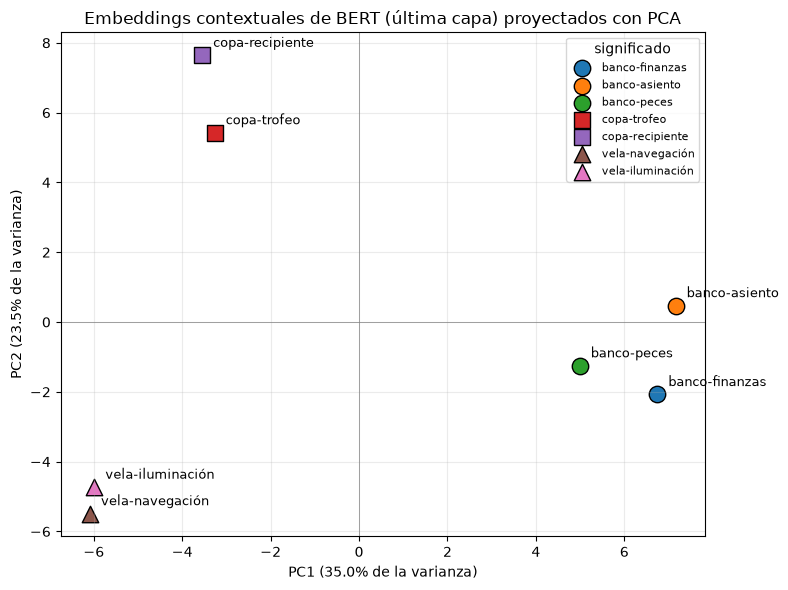

In [8]:
pca = PCA(n_components=2, random_state=SEED)
points = pca.fit_transform(bert_embeddings.numpy())
explained = pca.explained_variance_ratio_

print(f'Varianza explicada: PC1 = {explained[0]:.1%} | PC2 = {explained[1]:.1%} | total = {explained.sum():.1%}')
coordinates = pd.DataFrame(points.round(3), columns=['PC1', 'PC2'])
coordinates.insert(0, 'significado', meanings)
print(coordinates.to_string(index=False))

markers = {'banco': 'o', 'copa': 's', 'vela': '^'}
colors = plt.get_cmap('tab10').colors

fig, ax = plt.subplots(figsize=(8, 6))
for index, ((_, word, meaning), (x, y)) in enumerate(zip(SENTENCES, points)):
    ax.scatter(x, y, s=140, marker=markers[word], color=colors[index], edgecolor='black', label=meaning)
    ax.annotate(meaning, (x, y), textcoords='offset points', xytext=(8, 6), fontsize=9)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({explained[0]:.1%} de la varianza)')
ax.set_ylabel(f'PC2 ({explained[1]:.1%} de la varianza)')
ax.set_title('Embeddings contextuales de BERT (última capa) proyectados con PCA')
ax.legend(loc='best', fontsize=8, title='significado')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig('outputs/task3_pca.png', dpi=150)
plt.show()

assert points.shape == (len(SENTENCES), 2)

**Discusión.** Las dos componentes conservan el 58.6 % de la varianza (35.0 % + 23.5 %); el 41.4 % restante no se ve en el gráfico.

La separación dominante es **por palabra**, no por significado. Se forman tres grupos lejanos entre sí: `banco` a la derecha (PC1 entre 5.0 y 7.2), `copa` arriba a la izquierda (PC2 entre 5.4 y 7.6) y `vela` abajo a la izquierda (PC2 entre -5.5 y -4.7). La distancia entre grupos es de unas 12 unidades (por ejemplo, 12.5 entre `banco-finanzas` y `copa-trofeo`). Con siete puntos de tres palabras distintas, la mayor varianza la explica qué palabra es, y PCA dedica sus dos ejes a eso.

Dentro de cada palabra, los contextos distintos **sí se separan, pero mucho menos**:

- `banco`: los tres puntos no coinciden; están a distancias de 1.9 a 2.8 entre sí. `banco-finanzas` y `banco-peces` son el par más cercano (1.94), lo que coincide con su coseno más alto en la tabla de BERT (0.660).
- `copa`: trofeo y recipiente están a 2.24 de distancia, separados sobre todo en PC2.
- `vela`: navegación e iluminación quedan casi encimadas (0.77), lo que coincide con que es el par con mayor coseno (0.800).

La proyección no reproduce exactamente todas las relaciones: según el coseno, el par más distinto de `banco` es finanzas / asiento (0.575), pero en el plano el más alejado es asiento / peces (2.77 frente a 2.58). Es la pérdida de información esperable al pasar de 768 a 2 dimensiones; por eso la conclusión cuantitativa se basa en los cosenos y el PCA se usa como apoyo visual.

En conjunto: BERT ubica cada instancia en un punto distinto según su contexto, a diferencia de Word2Vec, donde las instancias de una misma palabra serían un solo punto. Pero en esta proyección la identidad de la palabra pesa más que su significado, y los distintos sentidos de una palabra quedan más cerca entre sí que de cualquier otra palabra.

## 8. Task 4.1 - preguntas de análisis

### a. La máscara causal y el objetivo de Language Modeling

El objetivo de Language Modeling es aprender $P(x_{t+1} \mid x_1, \dots, x_t)$, es decir, predecir el siguiente token viendo solo los anteriores. En el Task 1 lo vimos de forma concreta: durante el entrenamiento el modelo recibe un bloque completo y predice todas las posiciones a la vez, y el objetivo `y` es la misma entrada `x` corrida una posición. Esto significa que la respuesta de cada posición ya está dentro de la entrada, justo un lugar a la derecha. La máscara causal es lo único que impide que el modelo la vea: antes del softmax pone $-\infty$ en los scores de las posiciones futuras, su peso de atención queda en 0 y cada token solo puede atender a sí mismo y a los anteriores.

Si GPT usara atención bidireccional durante el preentrenamiento, cada posición podría atender a la siguiente y copiar el token que tiene que predecir. El modelo aprendería algo trivial, "copia al vecino de la derecha", en lugar de aprender cómo funciona el idioma. La loss bajaría casi a 0 y la perplejidad casi a 1, y esto pasaría también en validación, porque ahí el modelo también tiene el texto completo. Las métricas dirían que el modelo es casi perfecto y sería falso. El problema aparecería al generar: en ese momento el futuro todavía no existe, así que lo único que aprendió, copiar del futuro, ya no le sirve, y el texto generado no tendría sentido. Habría un desajuste entre cómo se entrenó el modelo y cómo se usa.

Por eso en el Task 1 verificamos que la parte triangular superior de los mapas de atención fuera exactamente 0 antes de entrenar. Esa verificación es la que garantiza que la perplejidad que reportamos mide una predicción real y no una copia.

BERT sí es bidireccional y no cae en esta trampa porque cambia la tarea de preentrenamiento. En lugar de ocultar el futuro en la atención, oculta palabras en la entrada con el token `[MASK]` y le pide al modelo adivinarlas. La respuesta nunca está en lo que el modelo ve, así que puede mirar a ambos lados sin hacer trampa. GPT oculta la respuesta en la atención y BERT la oculta en la entrada; son dos soluciones al mismo problema.

### b. Preentrenar y adaptar: elegir entre GPT y BERT según la tarea

La tensión viene de la misma máscara. GPT puede generar texto porque cada token solo ve hacia atrás, pero eso también le quita información para entender una palabra. BERT ve a ambos lados y entiende mejor el contexto, pero por eso mismo no puede generar de forma autoregresiva.

Nuestras oraciones del Task 3 muestran bien la parte de entender. En varias de ellas la pista que resuelve la ambigüedad aparece después de la palabra objetivo: "El banco **central**", "El banco **de peces**", "una copa **de vino**". Comparemos "El banco central anunció..." con "El banco de peces se movió...". Al llegar a `banco`, lo único que un modelo causal como GPT ha visto en ambas oraciones es "El". Como con la máscara causal la representación de una posición depende solo de los tokens anteriores, GPT produciría exactamente el mismo vector para las dos instancias, con coseno 1.0, igual que Word2Vec. Esto no lo medimos ejecutando un GPT, pero se deduce directamente de cómo funciona la máscara. BERT, en cambio, pudo ver "central" y "peces", y en ese par obtuvimos un coseno de 0.660. En el resto de los pares obtuvimos entre 0.567 y 0.800, mientras que Word2Vec dio 1.0 en todos.

El paradigma de preentrenar y adaptar resuelve la tensión porque no obliga a tener un solo modelo que haga todo bien. La parte cara, que es aprender el idioma a partir de un corpus enorme, la hace alguien una sola vez y publica los pesos. Nosotros solo elegimos el modelo que conviene para la tarea y lo adaptamos:

- Si la tarea es **entender** texto (desambiguar palabras, clasificar, medir similitud, reconocer entidades), conviene BERT, porque su atención bidireccional es justo lo que necesita. El Task 3 lo muestra: sin entrenar nada, cargamos el modelo y en unos minutos, en CPU, obtuvimos embeddings que distinguen los significados de `banco`, `copa` y `vela`.
- Si la tarea es **generar** texto (completar, resumir, conversar), conviene GPT, porque su máscara causal es lo que le permite producir un token tras otro.

La diferencia con entrenar desde cero también la vivimos en este laboratorio. Nuestro Mini-GPT del Task 1 tiene 609,985 parámetros, lo entrenamos desde cero con Tiny Shakespeare durante 10 épocas y terminó con una perplejidad de validación de 8.645, un poco por encima del rango esperado de 3.5 a 8.0, y genera palabras inventadas. BERT tiene 177,853,440 parámetros que no tuvimos que entrenar: Google ya hizo ese trabajo con Wikipedia en 104 idiomas, y nosotros solo tuvimos que cargarlo.

Adaptar puede significar distintas cosas según cuánto se quiera invertir: usar los embeddings tal como salen del modelo, que es lo que hicimos en el Task 3; agregar una capa encima y ajustar el modelo con pocos datos etiquetados (fine-tuning); o, en el caso de GPT, simplemente darle instrucciones en el prompt. En todos los casos partimos de un modelo que ya sabe el idioma, y la máscara causal deja de ser una limitación para convertirse en un criterio: nos dice qué modelo escoger para cada tarea.

## 9. Registro de uso de IA (Task 3 y Task 4)

**Prompt utilizado**

> Antes de hugginface, como podemos obtener modelos de ahi? mediante una libreria o un script de descarga?

**Qué se usó**

La explicación de qué es Hugging Face y cómo se obtienen sus modelos: el Hub como repositorio de modelos, la librería `transformers` como la forma de cargarlos, y el hecho de que `from_pretrained` descarga el modelo la primera vez y después lo lee de la caché local, sin necesidad de un script de descarga aparte. Con eso escribimos la celda de carga de BERT de la sección 2 y las verificaciones que la acompañan: la clase del modelo, el número de capas, la dimensión de 768, el tamaño del vocabulario multilingüe y el commit del repositorio descargado.

**Por qué funcionó**

Entender primero de dónde sale el modelo nos permitió comprobar que cargamos exactamente el que pide el enunciado, en lugar de confiar solo en el nombre. También nos ayudó a interpretar lo que apareció después: el aviso de pesos `UNEXPECTED` al cargar BERT y la descarga de Word2Vec con `gensim`, que sigue la misma idea de descargar una vez y guardar en caché. Todos los resultados y cifras del notebook salen de las celdas ejecutadas y se revisaron contra esas salidas antes de escribir las respuestas.